Feature matrix shape: (99995, 24), Target shape: (99995,)
Training samples: 79996, Test samples: 19999
Starting Genetic Algorithm optimisation...
gen	nevals	avg        	min    	max        
0  	20    	1.96531e+06	27.6336	2.02448e+07
1  	14    	126007     	12.9393	2.44406e+06
2  	9     	1158.72    	12.9393	21604.5    
3  	15    	5846.89    	12.9393	108530     
4  	15    	21.115     	10.3424	111.147    
5  	11    	12.2379    	9.29901	12.9393    
6  	13    	1.01178e+06	9.29901	2.02353e+07
7  	10    	10.6208    	9.29901	18.4422    
8  	13    	237.254    	9.29901	4362.14    
9  	10    	9.37084    	8.55963	11.475     
10 	6     	9.0772     	8.55963	9.29901    
11 	15    	8.63357    	8.55963	9.29901    
12 	15    	1041.42    	8.55963	20665.7    
13 	16    	1.01178e+06	8.55963	2.02354e+07
14 	14    	2063.29    	7.95314	20665.7    
15 	9     	1041.33    	7.95314	20665.7    
16 	13    	8.85497    	7.95314	17.4988    
17 	15    	8.28671    	7.95314	8.55963    
18 	14    	9.31854    	7.95314	32.351

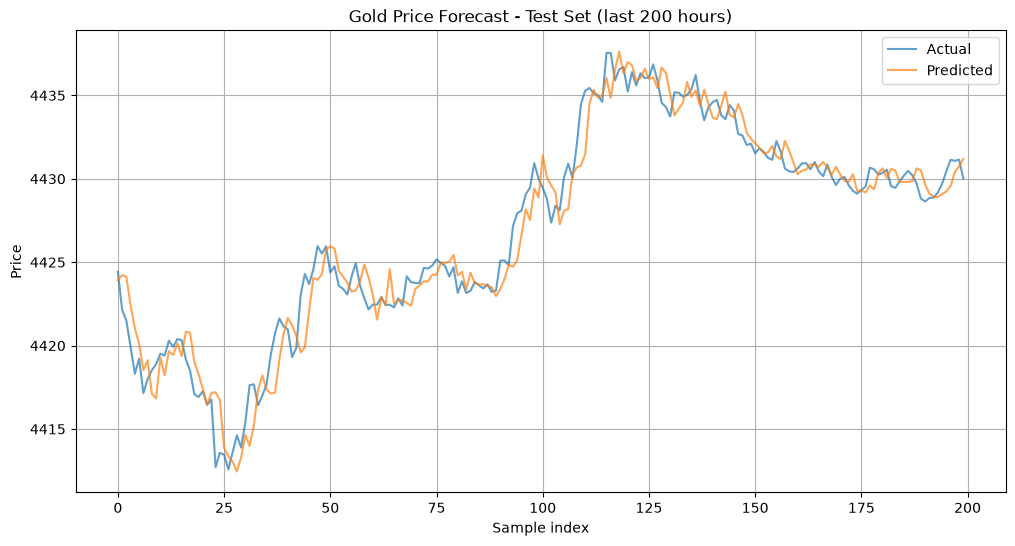

Model and scaler saved as 'best_mlp_model.pkl' and 'scaler.save'.

Exporting to ONNX...
ONNX model saved as 'gold_price_model.onnx'.
ONNX verification passed. Sample prediction: 4397.7090

All done! Files are saved in the current working directory.


In [4]:
# -*- coding: utf-8 -*-
"""
Gold Price Forecasting with GA‑optimized MLP – LOCAL VERSION
============================================================
Trains an MLP on hourly financial data using a Genetic Algorithm.
Saves model, scaler and ONNX file for use in MQL5.
"""

# -----------------------------------------------------------------------------
# 1. Import libraries
# -----------------------------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance
from deap import base, creator, tools, algorithms
import joblib
import onnx
from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import FloatTensorType
import warnings
warnings.filterwarnings('ignore')

# -----------------------------------------------------------------------------
# 2. Load and prepare your data
# -----------------------------------------------------------------------------
# !! CHANGE THIS FILENAME TO MATCH YOUR CSV !!
csv_file = 'GOLD.i#_M1_202605270346_202609042357-xm.csv'

data = pd.read_csv(csv_file, sep='\s+')  # space/tab separated

# Ensure datetime is parsed and set as index
if '<DATE>' in data.columns and '<TIME>' in data.columns:
    data['Datetime'] = pd.to_datetime(data['<DATE>'] + ' ' + data['<TIME>'])
    data.set_index('Datetime', inplace=True)
    data.drop(columns=['<DATE>', '<TIME>'], inplace=True)
elif 'Datetime' in data.columns:
    data['Datetime'] = pd.to_datetime(data['Datetime'])
    data.set_index('Datetime', inplace=True)
elif 'time' in data.columns:
    data['time'] = pd.to_datetime(data['time'])
    data.set_index('time', inplace=True)
else:
    raise ValueError("CSV must have a 'Datetime' or 'time' column (or '<DATE>' and '<TIME>').")

# Sort index to be safe
data.sort_index(inplace=True)

# -----------------------------------------------------------------------------
# 3. Feature engineering: create 4‑hour interval inputs
# -----------------------------------------------------------------------------
# Define the target variable (assuming 'Close' for XAUUSD_M5 data)
target_col = '<CLOSE>'

# Dynamically get all numerical columns as features, excluding the target column
feature_cols = [col for col in data.select_dtypes(include=np.number).columns if col != target_col]

# Verify target column exists
if target_col not in data.columns:
    raise ValueError(f"Column '{target_col}' not found in CSV. Please ensure the target column name is correct.")

# -----------------------------------------------------------------------------
# 4. Build input sets from 4 consecutive hourly intervals
# -----------------------------------------------------------------------------
def create_input_sets(df, feature_columns, target_col, intervals=4):
    """
    Creates features from `intervals` previous hours and the target for the next hour.
    Returns X (features) and y (target).
    """
    X_list = []
    y_list = []
    for i in range(intervals, len(df) - 1):
        features = []
        for lag in range(intervals, 0, -1):
            for col in feature_columns:
                features.append(df[col].iloc[i - lag])
        X_list.append(features)
        y_list.append(df[target_col].iloc[i + 1])  # Predict target at next time step
    return np.array(X_list), np.array(y_list)

X, y = create_input_sets(data, feature_cols, target_col, intervals=4)
print(f"Feature matrix shape: {X.shape}, Target shape: {y.shape}")

# -----------------------------------------------------------------------------
# 5. Scaling the data
# -----------------------------------------------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save the scaler for later use in MQL5.
joblib.dump(scaler, 'scaler.save')

# -----------------------------------------------------------------------------
# 6. Train/test split (temporal order preserved)
# -----------------------------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, shuffle=False
)

print(f"Training samples: {X_train.shape[0]}, Test samples: {X_test.shape[0]}")

# -----------------------------------------------------------------------------
# 7. Genetic Algorithm for MLP hyperparameter optimisation
# -----------------------------------------------------------------------------
# Set up DEAP
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

toolbox = base.Toolbox()

def random_neurons():
    return np.random.randint(10, 201, 1)[0] // 10 * 10  # multiple of 10

def random_activation():
    return np.random.choice(['logistic', 'tanh', 'relu'])

def random_solver():
    return np.random.choice(['adam', 'lbfgs', 'sgd'])

def random_alpha():
    return 10 ** np.random.uniform(-5, -2)

toolbox.register("neurons", random_neurons)
toolbox.register("activation", random_activation)
toolbox.register("solver", random_solver)
toolbox.register("alpha", random_alpha)

toolbox.register("individual", tools.initCycle, creator.Individual,
                 (toolbox.neurons, toolbox.activation, toolbox.solver, toolbox.alpha), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

def evaluate(individual):
    neurons, activation, solver, alpha = individual
    mlp = MLPRegressor(
        hidden_layer_sizes=(neurons,),
        activation=activation,
        solver=solver,
        alpha=alpha,
        max_iter=200,        # Limit iterations for speed during GA
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=10
    )
    try:
        mlp.fit(X_train, y_train)
        y_pred = mlp.predict(X_test)
        mse = mean_squared_error(y_test, y_pred)
        return (mse,)
    except Exception as e:
        return (1e10,)  # high penalty for failures

toolbox.register("evaluate", evaluate)
toolbox.register("mate", tools.cxTwoPoint)

def custom_mutate(individual):
    # Mutate neurons: add/subtract multiple of 10
    if np.random.rand() < 0.2:
        individual[0] = max(10, min(200, individual[0] + np.random.randint(-30, 31)//10*10))
    # Mutate activation
    if np.random.rand() < 0.2:
        individual[1] = np.random.choice(['logistic', 'tanh', 'relu'])
    # Mutate solver
    if np.random.rand() < 0.2:
        individual[2] = np.random.choice(['adam', 'lbfgs', 'sgd'])
    # Mutate alpha: add log-normal noise
    if np.random.rand() < 0.2:
        individual[3] = 10 ** (np.log10(individual[3]) + np.random.normal(0, 0.5))
        individual[3] = max(1e-5, min(1e-2, individual[3]))
    return individual,

toolbox.register("mutate", custom_mutate)
toolbox.register("select", tools.selTournament, tournsize=3)

# GA parameters
POPULATION_SIZE = 20
GENERATIONS = 40   # Increase to 40 for better results, but it will take longer

pop = toolbox.population(n=POPULATION_SIZE)
hof = tools.HallOfFame(1)
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("avg", np.mean)
stats.register("min", np.min)
stats.register("max", np.max)

print("Starting Genetic Algorithm optimisation...")
pop, log = algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.2, ngen=GENERATIONS,
                               stats=stats, halloffame=hof, verbose=True)

best_individual = hof[0]
best_neurons, best_activation, best_solver, best_alpha = best_individual
print(f"Best hyperparameters: neurons={best_neurons}, activation={best_activation}, "
      f"solver={best_solver}, alpha={best_alpha:.6f}")

# -----------------------------------------------------------------------------
# 8. Train final model with best parameters
# -----------------------------------------------------------------------------
best_mlp = MLPRegressor(
    hidden_layer_sizes=(best_neurons,),
    activation=best_activation,
    solver=best_solver,
    alpha=best_alpha,
    max_iter=1000,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20
)

best_mlp.fit(X_train, y_train)

# Predictions
y_pred_train = best_mlp.predict(X_train)
y_pred_test = best_mlp.predict(X_test)

# Metrics
def print_metrics(y_true, y_pred, set_name="Test"):
    r2 = r2_score(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    print(f"\n{set_name} Metrics:")
    print(f"R² Score:  {r2:.6f}")
    print(f"MSE:      {mse:.6f}")
    print(f"RMSE:     {rmse:.6f}")
    print(f"MAE:      {mae:.6f}")

print_metrics(y_train, y_pred_train, "Training")
print_metrics(y_test, y_pred_test, "Test")

# -----------------------------------------------------------------------------
# 9. Feature importance (permutation)
# -----------------------------------------------------------------------------
print("\nCalculating permutation importance on test set...")
perm_importance = permutation_importance(best_mlp, X_test, y_test, n_repeats=20, random_state=42)

# Map to feature names (for display)
feature_names = []
for lag in range(4, 0, -1):
    for col in feature_cols:
        feature_names.append(f"{col} (t-{lag})")

for i, name in enumerate(feature_names):
    print(f"{name}: {perm_importance.importances_mean[i]:.6f} ± {perm_importance.importances_std[i]:.6f}")

# -----------------------------------------------------------------------------
# 10. Visualisation: Predicted vs Actual
# -----------------------------------------------------------------------------
plt.figure(figsize=(12, 6))
plt.plot(y_test[-200:], label='Actual', alpha=0.7)
plt.plot(y_pred_test[-200:], label='Predicted', alpha=0.7)
plt.title("Gold Price Forecast - Test Set (last 200 hours)")
plt.xlabel("Sample index")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

# -----------------------------------------------------------------------------
# 11. Save model and scaler (local)
# -----------------------------------------------------------------------------
joblib.dump(best_mlp, 'best_mlp_model.pkl')
joblib.dump(scaler, 'scaler.save')
print("Model and scaler saved as 'best_mlp_model.pkl' and 'scaler.save'.")

# -----------------------------------------------------------------------------
# 12. Export to ONNX for MQL5 deployment
# -----------------------------------------------------------------------------
print("\nExporting to ONNX...")
initial_type = [('float_input', FloatTensorType([None, X.shape[1]]))]
onnx_model = convert_sklearn(best_mlp, initial_types=initial_type, target_opset=12)
with open("gold_price_model.onnx", "wb") as f:
    f.write(onnx_model.SerializeToString())
print("ONNX model saved as 'gold_price_model.onnx'.")

# Optionally, verify with onnxruntime
import onnxruntime as ort
session = ort.InferenceSession("gold_price_model.onnx")
dummy_input = X_test[:1].astype(np.float32)
outputs = session.run(None, {'float_input': dummy_input})
print(f"ONNX verification passed. Sample prediction: {outputs[0][0][0]:.4f}")

print("\nAll done! Files are saved in the current working directory.")

In [5]:
import joblib

# Load the saved scaler
loaded_scaler = joblib.load('scaler.save')

# Extract means and scales
feature_means = loaded_scaler.mean_
feature_scales = loaded_scaler.scale_

# Get the number of features
n_features = len(feature_means)

print(f"N_FEATURES: {n_features}")

# Format for C++ array
print("\ndouble feature_means[N_FEATURES] = {");
print("    " + ", ".join(f"{x:.6f}" for x in feature_means));
print("};\n");

print("double feature_scales[N_FEATURES] = {");
print("    " + ", ".join(f"{x:.6f}" for x in feature_scales));
print("};")

N_FEATURES: 24

double feature_means[N_FEATURES] = {
    4254.410065, 4255.455885, 4253.354615, 259.581389, 0.000000, 21.561848, 4254.409153, 4255.454969, 4253.353704, 259.579929, 0.000000, 21.561948, 4254.408245, 4255.454063, 4253.352790, 259.579779, 0.000000, 21.561908, 4254.407342, 4255.453157, 4253.351896, 259.578449, 0.000000, 21.562038
};

double feature_scales[N_FEATURES] = {
    195.766147, 195.777897, 195.751238, 118.789473, 1.000000, 4.858860, 195.765118, 195.776864, 195.750205, 118.790881, 1.000000, 4.859055, 195.764091, 195.775840, 195.749167, 118.791077, 1.000000, 4.859026, 195.763067, 195.774817, 195.748154, 118.792679, 1.000000, 4.859319
};
